# Exploratory Analysis on Piazza Discussion Forum Data
A work in progress.

## Imports

To get the data, fill out the Piazza form on the GitHub page.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import nltk
import string
from nltk.sentiment import SentimentIntensityAnalyzer
import collections
import seaborn as sb
from sklearn.metrics import cohen_kappa_score
import datetime

In [2]:
data = pd.read_excel(".data/Spring 2021 Coding Results_Piazza.xlsx", sheet_name = "a4_coding1")

## Cleaning the Comments

In [3]:
stop_words = nltk.corpus.stopwords.words('english')
def preprocess(sentence):
    words = [w for w in sentence.lower().split() if w not in stop_words]
    return [w for w in words if (w not in string.punctuation and w not in "??==")]
            
data["Post_pp"] = data["Submission HTML Removed"].apply(preprocess)

## What do the CP codes look like?

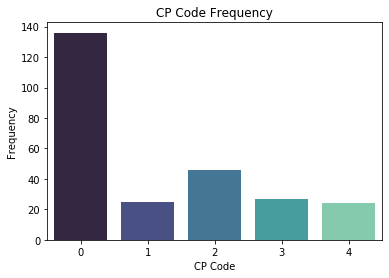

In [4]:
# Distribution of codes that we have
cp_codes = data["CP Code"]

c = collections.Counter(cp_codes)
c = sorted(c.items())
cp_num = [i[0] for i in c]
freq = [i[1] for i in c]

sb.barplot(cp_num, freq, palette="mako")
plt.title("CP Code Frequency")
plt.xlabel("CP Code")
plt.ylabel("Frequency")
plt.show()

In [5]:
# calculate Cohen's Kappa for agreement between the two raters
cohen_kappa_score(data['Coder1'], data['Coder2'])

0.9178624218305855

## Word Count

Post paragraph length by CP code

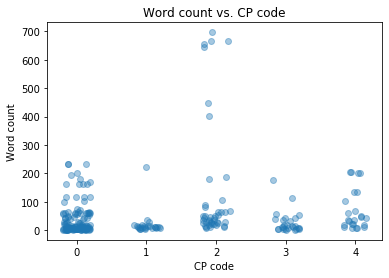

In [6]:
data["Words len"] = data["Post_pp"].str.len()
not_long = data["Words len"] < 1500
word_count_data_filtered = data[not_long]

sb.regplot(word_count_data_filtered["CP Code"], word_count_data_filtered["Words len"], 
           fit_reg = False, x_jitter = .2, scatter_kws={'alpha':0.4})
plt.xlabel("CP code")
plt.ylabel("Word count")
plt.title("Word count vs. CP code")
plt.show()

## Common Words

In [7]:
# frequency of words in all posts
all_words_list = data["Post_pp"].apply(pd.Series).stack().reset_index(drop=True)
fd = nltk.FreqDist(all_words_list)
words = fd.tabulate(20)

    return        def      split     please      class        use   features       tree   decision      none,    classes  features,        """ assignment   classes,      depth       &gt;       used      else:       part 
       177        142        112        110        104         99         98         97         93         85         74         74         73         71         64         64         62         60         60         60 


## Sentiment Analysis
https://www.digitalocean.com/community/tutorials/how-to-perform-sentiment-analysis-in-python-3-using-the-natural-language-toolkit-nltk

Just using the default VADER analyzer from NLTK for now, but I should create my own/adjust it.

In [8]:
# overall analysis
all_words = ' '.join(data["Submission HTML Removed"])
all_words_sia = nltk.sentiment.SentimentIntensityAnalyzer().polarity_scores(all_words)
all_words_sia

{'neg': 0.031, 'neu': 0.865, 'pos': 0.104, 'compound': 1.0}

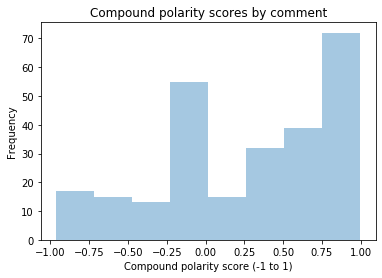

In [9]:
# analysis for each comment
data['sentiment'] = data["Submission HTML Removed"].apply(nltk.sentiment.SentimentIntensityAnalyzer().polarity_scores)
data[['pos', 'neu', 'neg', 'compound']] = data['sentiment'].apply(pd.Series)
sb.distplot(data['compound'], kde=False)
plt.xlabel("Compound polarity score (-1 to 1)")
plt.ylabel("Frequency")
plt.title("Compound polarity scores by comment")
plt.show()

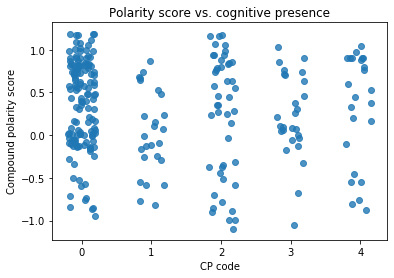

In [10]:
# Polarity scores by CP code
fig = sb.regplot(data=data, x="CP Code", y="compound", x_jitter=.2, y_jitter = .2, fit_reg = False)
plt.xlabel("CP code")
plt.ylabel("Compound polarity score")
plt.title("Polarity score vs. cognitive presence")
plt.show()

## Messages over Time

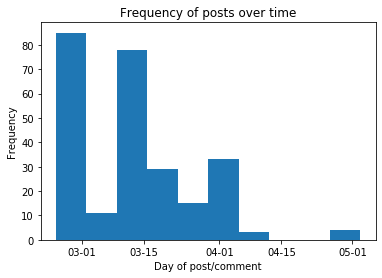

In [11]:
def string_to_datetime(str):
    return datetime.datetime.strptime(str, '%Y-%m-%d %H:%M:%S UTC')

data['created_time'] = data['Created At'].apply(string_to_datetime)
plt.hist(data['created_time'])
plt.gca().xaxis.set_major_formatter(DateFormatter('%m-%d'))
plt.xlabel("Day of post/comment")
plt.ylabel("Frequency")
plt.title("Frequency of posts over time")

plt.show()